In [1]:
import logging

logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger(__name__)

from pathlib import Path
import arbor as A
import numpy as np
from toric_spines_sim import (
    prepare_gap_junctions,
    prepare_ampa_synapses,
    make_simulator_parameter_bank,
    TSMorphology,
    TSRecipe,
)
from toric_spines_sim.events import (
    DTSModelEventGenerator,
    StochasticEventGenerator,
    FlatRateCurve,
)
from toric_spines_sim.viz import RasterPlotter, TimeSeriesPlotter
from jscip import ParameterBank
from toric_spines_sim.viz import (
    plot_morphology_3d,
    plot_morphology_frusta_3d,
    VizConfig,
)
from toric_spines_sim.geometry.sink import sink_endpoint_location_from_swc_file
from toric_spines_sim.utils import load_xyz_points
from toric_spines_sim.paths import get_swc_path, get_pointset_path

import matplotlib.pyplot as plt

from typing import Tuple

DEBUG:matplotlib:matplotlib data path: /home/jordan/repos/toric_spines_sim/.venv/lib/python3.12/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/home/jordan/.config/matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is linux
DEBUG:matplotlib:CACHEDIR=/home/jordan/.cache/matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /home/jordan/.cache/matplotlib/fontlist-v390.json


# Integration study of TS1 with sink

First, we set up a function to do the simulation for a given set of input rates and parameters.

In [2]:
swc_filepath = get_swc_path("TS1_wsink_r20um.swc", units="microns")
synpts_filepath = get_pointset_path("TS1_synpts.txt", units="microns")
total_synapses = len(load_xyz_points(synpts_filepath))
model_name = "ts1"

logger.info(f"{model_name} has {total_synapses} synapses")

sink_endpoint = sink_endpoint_location_from_swc_file(swc_filepath)
logger.info(f"Sink endpoint: {sink_endpoint}")

INFO:__main__:ts1 has 25 synapses
INFO:swctools.io:parse_swc start strict=True validate_reconnections=True float_tol=1e-09
DEBUG:swctools.io:reconnect header i=53 j=10 line=5
DEBUG:swctools.io:reconnect header i=54 j=7 line=6
DEBUG:swctools.io:reconnect header i=55 j=2 line=7
DEBUG:swctools.io:reconnect header i=56 j=8 line=8
DEBUG:swctools.io:reconnect header i=57 j=23 line=9
DEBUG:swctools.io:reconnect header i=58 j=13 line=10
DEBUG:swctools.io:reconnect header i=59 j=19 line=11
INFO:swctools.io:parse_swc done records=65 reconnections=7 header=12
INFO:swctools.model:SWCModel.from_parse_result records=65 reconnections=7 header=12
INFO:swctools.model:SWCModel.from_swc_file built nodes=65 edges=64 strict=True validate_reconnections=True
INFO:__main__:Sink endpoint: (25.18596, 51.876592, 10.965944)


In [3]:
def simulation(
    swc_filepath,
    synpts_filepath,
    input_rates_hz,
    parameter_bank,
    record_point,
    event_type="poisson",
):
    synapses = prepare_ampa_synapses(synpts_filepath, parameter_bank=parameter_bank)
    record_points = {"probe_0": record_point}  # single record point
    gap_junctions = prepare_gap_junctions(swc_filepath)
    synapse_labels = list(synapses.keys())
    # Create per-axon rate curves (one per input channel)
    curves = [FlatRateCurve(r) for r in input_rates_hz]
    n_synapses = len(input_rates_hz)

    if event_type == "periodic":
        # ICPeriodicEvents -> DeterministicEventGenerator (independent mode)
        event_generator = DeterministicEventGenerator(
            rate_curves=curves,
            n_synapses_per_axon=[1] * n_synapses,
            T_ms=parameter_bank.get_value("T_ms"),
            delay_ms=parameter_bank.get_value("delay_ms"),
            labels=synapse_labels,
        )
    elif event_type == "poisson":
        # ICPoissonEvents -> StochasticEventGenerator (independent mode)
        event_generator = StochasticEventGenerator(
            rate_curves=curves,
            n_synapses_per_axon=[1] * n_synapses,
            T_ms=parameter_bank.get_value("T_ms"),
            delay_ms=parameter_bank.get_value("delay_ms"),
            seed=parameter_bank.get_value("seed"),
            labels=synapse_labels,
        )
    else:
        raise ValueError("event_type must be 'periodic' or 'poisson'")
    events = event_generator.generate()
    tsm = TSMorphology(
        swc_path=swc_filepath,
        synapses=synapses,
        gap_junctions=gap_junctions,
        record_points=record_points,
        parameter_bank=parameter_bank,
    )
    build_cell_results = tsm.build_cell()
    cell = build_cell_results["cell"]
    recipe = TSRecipe(
        cell,
        synapses=synapses,
        gap_junctions=gap_junctions,
        record_points=record_points,
        events=events,
        parameter_bank=parameter_bank,
    )
    ctx = A.context()
    dec = A.partition_load_balance(recipe, ctx)
    sim = A.simulation(recipe, ctx, dec)
    dt_record_ms = parameter_bank.get_value("dt_record_ms")
    handle = sim.sample(0, "v_probe_0", A.regular_schedule(dt_record_ms * A.units.ms))
    sim.record(A.spike_recording.all)
    T_ms = parameter_bank.get_value("T_ms")
    dt_sim_ms = parameter_bank.get_value("dt_sim_ms")
    sim.run(T_ms * A.units.ms, dt_sim_ms * A.units.ms)
    simulation_results = {
        "probe": sim.samples(handle),
        "events": events,
        "synapses": synapses,
        "gap_junctions": gap_junctions,
        "record_points": record_points,
        "cell": cell,
        "morphology": build_cell_results["morphology"],
        "segment_tree": build_cell_results["segment_tree"],
        "decor": build_cell_results["decor"],
        "labels": build_cell_results["labels"],
        "cvp": build_cell_results["cvp"],
    }
    return simulation_results

In [4]:
parameter_bank = make_simulator_parameter_bank()
parameter_bank["T_ms"].value = 500.0
parameter_bank["discretization_um"].value = 1.0
parameter_bank["sink_radii_scale"].value = 1.0
parameter_bank["cm_uF_per_cm2"].value = (
    2.0  # default = 0.01 uF/cm^2, analysis from Sanculi gives O(1 uF/cm^2)
)
parameter_bank["rL_ohm_cm"].value = 150
# hh
hh_on = False
hh_scale = 0.05
parameter_bank["hh_leak_e_mV"].value = -54.3
if hh_on:
    parameter_bank["K_gbar_S_per_cm2"].value = 0.036 * hh_scale  # hh value = 0.036
    parameter_bank["Na_gbar_S_per_cm2"].value = 0.12 * hh_scale  # hh value = 0.12
    parameter_bank["hh_leak_g_S_per_cm2"].value = 0.0003
else:
    parameter_bank["K_gbar_S_per_cm2"].value = 0.0
    parameter_bank["Na_gbar_S_per_cm2"].value = 0.0
    parameter_bank["hh_leak_g_S_per_cm2"].value = 0.0
# passive leak
leak_on = True
if leak_on:
    parameter_bank["pas_leak_g_S_per_cm2"].value = (
        0.001  # default = 0.001 ( 1 / 1000 Ohms * cm^2 )
    )
else:
    parameter_bank["pas_leak_g_S_per_cm2"].value = 0.0
# synapse parameters
parameter_bank["ampa_gmax_uS"].value = 0.1
parameter_bank["ampa_tau_ms"].value = 2.0

print("Parameter bank:\n", parameter_bank)

DEBUG:jscip.parameters:Validated value and range of IndependentScalarParameter: value 0, range None
DEBUG:jscip.parameters:Initialized IndependentScalarParameter with value 0, range None, is_sampled False
DEBUG:jscip.parameters:Validated value and range of IndependentScalarParameter: value 500.0, range None
DEBUG:jscip.parameters:Initialized IndependentScalarParameter with value 500.0, range None, is_sampled False
DEBUG:jscip.parameters:Validated value and range of IndependentScalarParameter: value 50.0, range None
DEBUG:jscip.parameters:Initialized IndependentScalarParameter with value 50.0, range None, is_sampled False
DEBUG:jscip.parameters:Validated value and range of IndependentScalarParameter: value 0.1, range None
DEBUG:jscip.parameters:Initialized IndependentScalarParameter with value 0.1, range None, is_sampled False
DEBUG:jscip.parameters:Validated value and range of IndependentScalarParameter: value 0.02, range None
DEBUG:jscip.parameters:Initialized IndependentScalarParamet

Parameter bank:
 ParameterBank(parameters={'seed': IndependentScalarParameter(value=0, range=None, is_sampled=False), 'T_ms': IndependentScalarParameter(value=500.0, range=None, is_sampled=False), 'delay_ms': IndependentScalarParameter(value=50.0, range=None, is_sampled=False), 'discretization_um': IndependentScalarParameter(value=1.0, range=None, is_sampled=False), 'dt_sim_ms': IndependentScalarParameter(value=0.02, range=None, is_sampled=False), 'dt_record_ms': IndependentScalarParameter(value=0.1, range=None, is_sampled=False), 'spine_tag': IndependentScalarParameter(value=3, range=None, is_sampled=False), 'sink_tag': IndependentScalarParameter(value=5, range=None, is_sampled=False), 'sink_radii_scale': IndependentScalarParameter(value=1.0, range=None, is_sampled=False), 'neck_radius_scale': IndependentScalarParameter(value=1.0, range=None, is_sampled=False), 'temp_K': IndependentScalarParameter(value=313.15, range=None, is_sampled=False), 'Vrest_mV': IndependentScalarParameter(valu

DEBUG:toric_spines_sim.synapse:Prepared 25 synapses from /home/jordan/repos/toric_spines_sim/data/pointsets/microns/TS1_synpts.txt using mechanism=ampa gmax_uS=None tau_ms=None
INFO:swctools.io:parse_swc start strict=True validate_reconnections=False float_tol=1e-09
DEBUG:swctools.io:reconnect header i=53 j=10 line=5
DEBUG:swctools.io:reconnect header i=54 j=7 line=6
DEBUG:swctools.io:reconnect header i=55 j=2 line=7
DEBUG:swctools.io:reconnect header i=56 j=8 line=8
DEBUG:swctools.io:reconnect header i=57 j=23 line=9
DEBUG:swctools.io:reconnect header i=58 j=13 line=10
DEBUG:swctools.io:reconnect header i=59 j=19 line=11
INFO:swctools.io:parse_swc done records=65 reconnections=7 header=12
DEBUG:toric_spines_sim.swc:Parsed 7 cycle break reconnect pairs from /home/jordan/repos/toric_spines_sim/data/swc/microns/TS1_wsink_r20um.swc
INFO:swctools.io:parse_swc start strict=True validate_reconnections=False float_tol=1e-09
DEBUG:swctools.io:reconnect header i=53 j=10 line=5
DEBUG:swctools.io

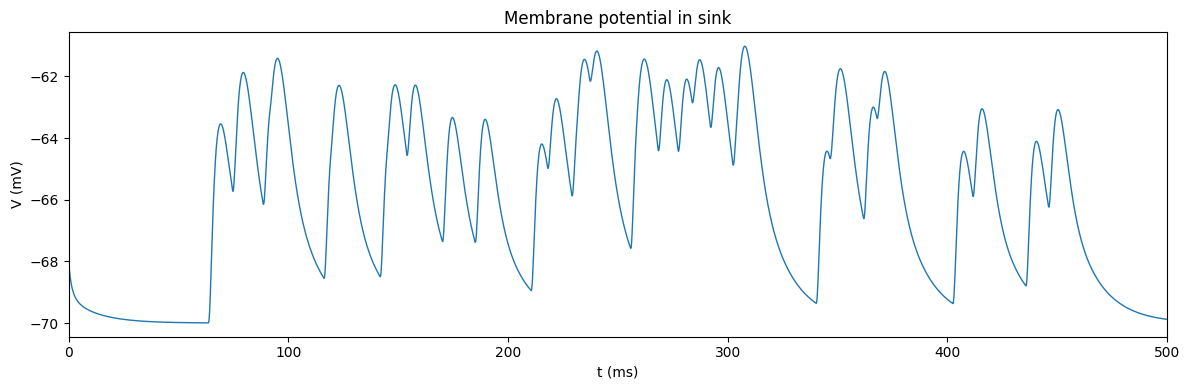

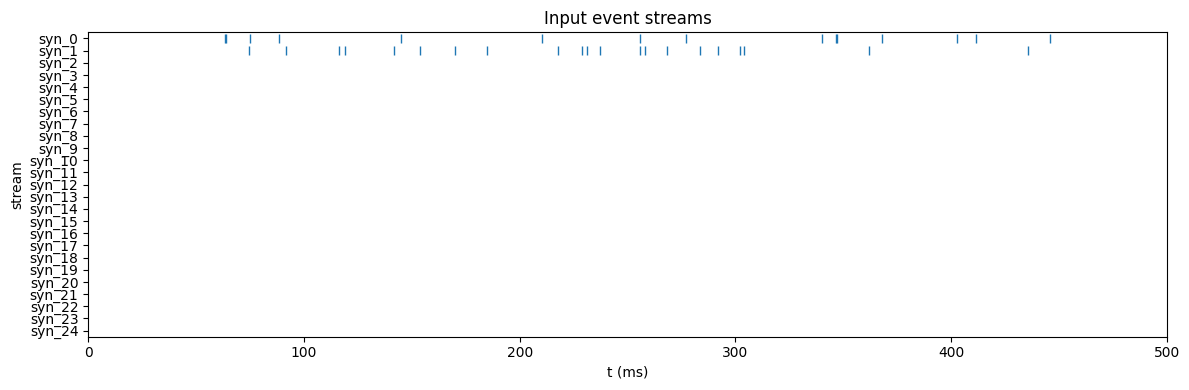

In [5]:
input_rates_hz = [0.0] * total_synapses
input_rates_hz[0] = input_rates_hz[1] = 50.0

results = simulation(
    swc_filepath,
    synpts_filepath,
    input_rates_hz,
    parameter_bank,
    record_point=sink_endpoint,
    event_type="poisson",
)
plotter_ts = TimeSeriesPlotter(
    title="Membrane potential in sink",
    xlim=(0, parameter_bank["T_ms"].value),
    figsize=(12, 4),
)
plotter_ts.add_time_series_from_arbor(results["probe"])
plotter_ts.show()
plotter_rp = RasterPlotter(
    title="Input event streams", xlim=(0, parameter_bank["T_ms"].value), figsize=(12, 4)
)
plotter_rp.add_streams(results["events"])
plotter_rp.show()